In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import seaborn as sns
from pathlib import Path
import plotly.graph_objects as go
pio.renderers.default = "notebook_connected"

In [2]:
path = r'C:\Data_analysis\Thesis\Data\02_Preprocessing\LF_data_droped.csv'
df = pd.read_csv(path,sep=',')
df.head(5)

,Time,BA_Soc,BU_TotActPwr_Academy,BA_TotActPwr_BESS_AC_Panel1,BA_TotActPwr_BESS_AC_Panel2,BU_TotActPwr_SDB_EL_Substation,BU_TotActPwr_Tech_Room,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum
0,2025-10-15 00:00:00,83.4,4.148,1.630,0.419,NaN,3.614,129.0,-4.6,83.5
1,2025-10-15 00:05:00,83.4,3.631,1.632,0.421,NaN,3.608,129.0,-4.3,83.8
2,2025-10-15 00:10:00,83.3,3.572,1.633,0.420,NaN,3.646,127.0,-4.7,84.1
3,2025-10-15 00:15:00,83.2,3.663,1.636,0.418,NaN,3.601,127.0,-4.5,84.3
4,2025-10-15 00:20:00,83.1,3.610,1.634,0.426,NaN,3.646,126.0,-4.5,85.0


In [3]:
df['Time'] = pd.to_datetime(df['Time'], errors = 'coerce')
df.set_index('Time', inplace=True)

In [4]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


                                missing_count  missing_pct
BU_TotActPwr_SDB_EL_Substation           7121        21.13
BA_Soc                                   2551         7.57
PV_WS_Radiation                          1399         4.15
PV_WS_AirTemp                            1397         4.15
PV_WS_RelHum                             1382         4.10
BU_TotActPwr_Tech_Room                    360         1.07
BU_TotActPwr_Academy                      357         1.06
BA_TotActPwr_BESS_AC_Panel1               334         0.99
BA_TotActPwr_BESS_AC_Panel2               331         0.98

Rows with any missing values: 9428


In [5]:
# Ensure datetime index
df.index = pd.to_datetime(df.index, errors="coerce")

# Remove invalid datetime index rows
df = df[~df.index.isna()].copy()

# Sort by time
df = df.sort_index()

# Optional but good
df = df[~df.index.duplicated(keep="first")].copy()

print(df.index.dtype)

datetime64[us]


In [6]:
print(df.shape)
print(df.columns)

(33696, 9)
Index(['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
       'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum'],
      dtype='str')


### create calendar features

In [7]:
idx = df.index

# Basic calendar features
df["dayofweek"] = idx.dayofweek                 # Monday=0, Sunday=6
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["hour"] = idx.hour
df["month"] = idx.month
df["dayofmonth"] = idx.day

# Time of day
df["minute_of_day"] = idx.hour * 60 + idx.minute

# Cyclical encoding for time of day
df["sin_tod"] = np.sin(2 * np.pi * df["minute_of_day"] / 1440)
df["cos_tod"] = np.cos(2 * np.pi * df["minute_of_day"] / 1440)

# Cyclical encoding for day of week
df["sin_dow"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["cos_dow"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Optional business-hours flag
df["is_business_hours"] = (
    (idx.hour >= 8) & (idx.hour < 18) & (df["dayofweek"] < 5)
).astype(int)

In [8]:
print(df.shape)
print(df.columns)

(33696, 20)
Index(['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
       'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum', 'dayofweek', 'is_weekend', 'hour', 'month',
       'dayofmonth', 'minute_of_day', 'sin_tod', 'cos_tod', 'sin_dow',
       'cos_dow', 'is_business_hours'],
      dtype='str')


### create lag features

In [9]:
load_cols = ['BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2',
       'BU_TotActPwr_Tech_Room']   #'BU_TotActPwr_SDB_EL_Substation' is excluded for now

lags = [1,3, 12, 36, 288]

# create lag features
for col in load_cols:
    for lag in lags:
        df[f"{col}_lag_{lag}"] = df[col].shift(lag)

In [10]:
print(df.shape)
print(df.columns)

(33696, 40)
Index(['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1',
       'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation',
       'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum', 'dayofweek', 'is_weekend', 'hour', 'month',
       'dayofmonth', 'minute_of_day', 'sin_tod', 'cos_tod', 'sin_dow',
       'cos_dow', 'is_business_hours', 'BU_TotActPwr_Academy_lag_1',
       'BU_TotActPwr_Academy_lag_3', 'BU_TotActPwr_Academy_lag_12',
       'BU_TotActPwr_Academy_lag_36', 'BU_TotActPwr_Academy_lag_288',
       'BA_TotActPwr_BESS_AC_Panel1_lag_1',
       'BA_TotActPwr_BESS_AC_Panel1_lag_3',
       'BA_TotActPwr_BESS_AC_Panel1_lag_12',
       'BA_TotActPwr_BESS_AC_Panel1_lag_36',
       'BA_TotActPwr_BESS_AC_Panel1_lag_288',
       'BA_TotActPwr_BESS_AC_Panel2_lag_1',
       'BA_TotActPwr_BESS_AC_Panel2_lag_3',
       'BA_TotActPwr_BESS_AC_Panel2_lag_12',
       'BA_TotActPwr_BESS_AC_Panel2_lag_36',
       'BA_TotActPwr_BESS_AC

### create rolling mean / rolling std

In [11]:
rolling_windows = [12, 36, 288]

for col in load_cols:
    for win in rolling_windows:
        df[f"{col}_roll_mean_{win}"] = df[col].shift(1).rolling(win).mean()

    # rolling std for selected windows
    df[f"{col}_roll_std_12"] = df[col].shift(1).rolling(12).std()
    df[f"{col}_roll_std_36"] = df[col].shift(1).rolling(36).std()

In [12]:
print(df.shape)
print(df.columns.tolist())

(33696, 60)
['BA_Soc', 'BU_TotActPwr_Academy', 'BA_TotActPwr_BESS_AC_Panel1', 'BA_TotActPwr_BESS_AC_Panel2', 'BU_TotActPwr_SDB_EL_Substation', 'BU_TotActPwr_Tech_Room', 'PV_WS_AirTemp', 'PV_WS_Radiation', 'PV_WS_RelHum', 'dayofweek', 'is_weekend', 'hour', 'month', 'dayofmonth', 'minute_of_day', 'sin_tod', 'cos_tod', 'sin_dow', 'cos_dow', 'is_business_hours', 'BU_TotActPwr_Academy_lag_1', 'BU_TotActPwr_Academy_lag_3', 'BU_TotActPwr_Academy_lag_12', 'BU_TotActPwr_Academy_lag_36', 'BU_TotActPwr_Academy_lag_288', 'BA_TotActPwr_BESS_AC_Panel1_lag_1', 'BA_TotActPwr_BESS_AC_Panel1_lag_3', 'BA_TotActPwr_BESS_AC_Panel1_lag_12', 'BA_TotActPwr_BESS_AC_Panel1_lag_36', 'BA_TotActPwr_BESS_AC_Panel1_lag_288', 'BA_TotActPwr_BESS_AC_Panel2_lag_1', 'BA_TotActPwr_BESS_AC_Panel2_lag_3', 'BA_TotActPwr_BESS_AC_Panel2_lag_12', 'BA_TotActPwr_BESS_AC_Panel2_lag_36', 'BA_TotActPwr_BESS_AC_Panel2_lag_288', 'BU_TotActPwr_Tech_Room_lag_1', 'BU_TotActPwr_Tech_Room_lag_3', 'BU_TotActPwr_Tech_Room_lag_12', 'BU_TotAct

### Drop NaN from target & starting due to lagg

In [13]:
df.head(5)

,BA_Soc,BU_TotActPwr_Academy,BA_TotActPwr_BESS_AC_Panel1,BA_TotActPwr_BESS_AC_Panel2,BU_TotActPwr_SDB_EL_Substation,BU_TotActPwr_Tech_Room,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,...,BA_TotActPwr_BESS_AC_Panel2_roll_mean_12,BA_TotActPwr_BESS_AC_Panel2_roll_mean_36,BA_TotActPwr_BESS_AC_Panel2_roll_mean_288,BA_TotActPwr_BESS_AC_Panel2_roll_std_12,BA_TotActPwr_BESS_AC_Panel2_roll_std_36,BU_TotActPwr_Tech_Room_roll_mean_12,BU_TotActPwr_Tech_Room_roll_mean_36,BU_TotActPwr_Tech_Room_roll_mean_288,BU_TotActPwr_Tech_Room_roll_std_12,BU_TotActPwr_Tech_Room_roll_std_36
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-15 00:00:00,83.4,4.148,1.630,0.419,NaN,3.614,129.0,-4.6,83.5,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:05:00,83.4,3.631,1.632,0.421,NaN,3.608,129.0,-4.3,83.8,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:10:00,83.3,3.572,1.633,0.420,NaN,3.646,127.0,-4.7,84.1,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:15:00,83.2,3.663,1.636,0.418,NaN,3.601,127.0,-4.5,84.3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-10-15 00:20:00,83.1,3.610,1.634,0.426,NaN,3.646,126.0,-4.5,85.0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] > 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


                                           missing_count  missing_pct
BU_TotActPwr_Academy_roll_mean_288                  9439        28.01
BU_TotActPwr_SDB_EL_Substation                      7121        21.13
BU_TotActPwr_Tech_Room_roll_mean_288                7040        20.89
BA_TotActPwr_BESS_AC_Panel1_roll_mean_288           4114        12.21
BA_TotActPwr_BESS_AC_Panel2_roll_mean_288           4041        11.99
BA_Soc                                              2551         7.57
BU_TotActPwr_Academy_roll_mean_36                   1567         4.65
BU_TotActPwr_Academy_roll_std_36                    1567         4.65
PV_WS_Radiation                                     1399         4.15
PV_WS_AirTemp                                       1397         4.15
PV_WS_RelHum                                        1382         4.10
BU_TotActPwr_Tech_Room_roll_mean_36                 1321         3.92
BU_TotActPwr_Tech_Room_roll_std_36                  1321         3.92
BA_TotActPwr_BESS_AC

In [15]:
# 5-minute data -> 1 day = 288 rows
startup_rows = 600

df.iloc[:startup_rows].isna().sum().sort_values(ascending=False)

BU_TotActPwr_SDB_EL_Substation               600
BU_TotActPwr_Academy_lag_288                 288
BA_TotActPwr_BESS_AC_Panel2_lag_288          288
BA_TotActPwr_BESS_AC_Panel1_lag_288          288
BU_TotActPwr_Tech_Room_lag_288               288
BA_TotActPwr_BESS_AC_Panel1_roll_mean_288    288
BU_TotActPwr_Tech_Room_roll_mean_288         288
BA_TotActPwr_BESS_AC_Panel2_roll_mean_288    288
BU_TotActPwr_Academy_roll_mean_288           288
BU_TotActPwr_Tech_Room_lag_36                 36
BU_TotActPwr_Academy_lag_36                   36
BA_TotActPwr_BESS_AC_Panel1_roll_std_36       36
BA_TotActPwr_BESS_AC_Panel1_lag_36            36
BA_TotActPwr_BESS_AC_Panel2_lag_36            36
BU_TotActPwr_Academy_roll_mean_36             36
BU_TotActPwr_Academy_roll_std_36              36
BA_TotActPwr_BESS_AC_Panel2_roll_mean_36      36
BU_TotActPwr_Tech_Room_roll_mean_36           36
BA_TotActPwr_BESS_AC_Panel1_roll_mean_36      36
BU_TotActPwr_Tech_Room_roll_std_36            36
BA_TotActPwr_BESS_AC

In [16]:
def build_target_df(
    df: pd.DataFrame,
    target_col: str,
    support_cols: list[str],
    *,
    add_calendar: bool = True
) -> pd.DataFrame:
    
    out = df.copy()

    calendar_cols = []
    if add_calendar:
        calendar_cols = [
            "dayofweek", "is_weekend", "hour", "month", "dayofmonth",
            "minute_of_day", "sin_tod", "cos_tod",
            "sin_dow", "cos_dow", "is_business_hours"
        ]

    lag_cols = [c for c in out.columns if c.startswith(f"{target_col}_lag_")]
    roll_cols = [c for c in out.columns if c.startswith(f"{target_col}_roll_")]

    selected_cols = [target_col] + support_cols + calendar_cols + lag_cols + roll_cols

    # keep only columns that actually exist
    selected_cols = [c for c in selected_cols if c in out.columns]

    out = out[selected_cols].copy()
    return out

In [17]:
def clean_target_df(
    df_target: pd.DataFrame,
    target_col: str,
    *,
    drop_startup: bool = True,
    startup_rows: int = 288
) -> pd.DataFrame:

    out = df_target.copy()

    if drop_startup:
        out = out.iloc[startup_rows:].copy()

    # Drop rows where target is NaN
    out = out[out[target_col].notna()].copy()

    return out

In [18]:
support_cols = ['BA_Soc', 'PV_WS_AirTemp','PV_WS_Radiation', 'PV_WS_RelHum'] 

In [19]:
df_BU_TotActPwr_Academy = build_target_df(df, target_col="BU_TotActPwr_Academy", support_cols=support_cols)
df_BU_TotActPwr_Tech_Room = build_target_df(df, target_col="BU_TotActPwr_Tech_Room", support_cols=support_cols)
df_BA_TotActPwr_BESS_AC_Panel1 = build_target_df(df, target_col="BA_TotActPwr_BESS_AC_Panel1", support_cols=support_cols)
df_BA_TotActPwr_BESS_AC_Panel2 = build_target_df(df, target_col="BA_TotActPwr_BESS_AC_Panel2", support_cols=support_cols)

In [20]:
df_BU_TotActPwr_Academy = clean_target_df(df_BU_TotActPwr_Academy, target_col="BU_TotActPwr_Academy", drop_startup=True, startup_rows=288)
df_BU_TotActPwr_Tech_Room = clean_target_df(df_BU_TotActPwr_Tech_Room, target_col="BU_TotActPwr_Tech_Room", drop_startup=True, startup_rows=288)
df_BA_TotActPwr_BESS_AC_Panel1 = clean_target_df(df_BA_TotActPwr_BESS_AC_Panel1, target_col="BA_TotActPwr_BESS_AC_Panel1", drop_startup=True, startup_rows=288)
df_BA_TotActPwr_BESS_AC_Panel2 = clean_target_df(df_BA_TotActPwr_BESS_AC_Panel2, target_col="BA_TotActPwr_BESS_AC_Panel2", drop_startup=True, startup_rows=288)

In [21]:
print(df_BU_TotActPwr_Academy.shape)
print(df_BU_TotActPwr_Academy.columns)

(33051, 26)
Index(['BU_TotActPwr_Academy', 'BA_Soc', 'PV_WS_AirTemp', 'PV_WS_Radiation',
       'PV_WS_RelHum', 'dayofweek', 'is_weekend', 'hour', 'month',
       'dayofmonth', 'minute_of_day', 'sin_tod', 'cos_tod', 'sin_dow',
       'cos_dow', 'is_business_hours', 'BU_TotActPwr_Academy_lag_1',
       'BU_TotActPwr_Academy_lag_3', 'BU_TotActPwr_Academy_lag_12',
       'BU_TotActPwr_Academy_lag_36', 'BU_TotActPwr_Academy_lag_288',
       'BU_TotActPwr_Academy_roll_mean_12',
       'BU_TotActPwr_Academy_roll_mean_36',
       'BU_TotActPwr_Academy_roll_mean_288',
       'BU_TotActPwr_Academy_roll_std_12', 'BU_TotActPwr_Academy_roll_std_36'],
      dtype='str')


In [22]:
df_BU_TotActPwr_Academy.head(10)

,BU_TotActPwr_Academy,BA_Soc,PV_WS_AirTemp,PV_WS_Radiation,PV_WS_RelHum,dayofweek,is_weekend,hour,month,dayofmonth,...,BU_TotActPwr_Academy_lag_1,BU_TotActPwr_Academy_lag_3,BU_TotActPwr_Academy_lag_12,BU_TotActPwr_Academy_lag_36,BU_TotActPwr_Academy_lag_288,BU_TotActPwr_Academy_roll_mean_12,BU_TotActPwr_Academy_roll_mean_36,BU_TotActPwr_Academy_roll_mean_288,BU_TotActPwr_Academy_roll_std_12,BU_TotActPwr_Academy_roll_std_36
Time,,,,,,,,,,,,,,,,,,,,,
2025-10-16 00:00:00,3.705,83.7,131.0,-4.2,84.5,3,0,0,10,16,...,3.774,4.910,4.764,4.416,4.148,4.293000,4.308306,6.826337,0.373116,0.517125
2025-10-16 00:05:00,3.750,83.6,131.0,-4.2,84.9,3,0,0,10,16,...,3.705,4.585,4.063,4.048,3.631,4.204750,4.288556,6.824799,0.376807,0.526389
2025-10-16 00:10:00,3.724,83.5,130.0,-4.1,85.1,3,0,0,10,16,...,3.750,3.774,4.085,3.956,3.572,4.178667,4.280278,6.825212,0.397762,0.532586
2025-10-16 00:15:00,3.773,83.4,129.0,-4.0,85.2,3,0,0,10,16,...,3.724,3.705,4.086,4.109,3.663,4.148583,4.273833,6.825740,0.418596,0.537998
2025-10-16 00:20:00,3.868,83.4,129.0,-3.9,85.4,3,0,0,10,16,...,3.773,3.750,4.095,4.113,3.610,4.122500,4.264500,6.826122,0.432375,0.543823
2025-10-16 00:25:00,3.728,83.2,129.0,-3.7,85.6,3,0,0,10,16,...,3.868,3.724,4.080,3.943,3.667,4.103583,4.257694,6.827017,0.438608,0.547295
2025-10-16 00:30:00,3.860,83.2,129.0,-3.6,85.6,3,0,0,10,16,...,3.728,3.773,3.976,5.836,3.663,4.074250,4.251722,6.827229,0.451898,0.551980
2025-10-16 00:35:00,3.900,83.1,129.0,-3.6,85.7,3,0,0,10,16,...,3.860,3.868,4.793,3.996,3.599,4.064583,4.196833,6.827913,0.455418,0.483998
2025-10-16 00:40:00,3.841,83.0,128.0,-3.8,85.9,3,0,0,10,16,...,3.900,3.728,4.305,4.175,3.629,3.990167,4.194167,6.828958,0.394451,0.485399


In [23]:
#### Missing Value check

# missing values summary by ech features (count and percent)
missing_count = df_BU_TotActPwr_Academy.isnull().sum()
missing_pct = (df_BU_TotActPwr_Academy.isnull().mean() * 100).round(2)
missing_summary = pd.concat([missing_count, missing_pct], axis=1)
missing_summary.columns = ['missing_count', 'missing_pct']
missing_summary = missing_summary.sort_values('missing_count', ascending=False)

if missing_summary['missing_count'].sum() == 0:
    print("No missing values found.")
else:
    print(missing_summary[missing_summary['missing_count'] >= 0])

    # number of rows with any missing value and a sample of such rows
    n_rows_with_missing = df_BU_TotActPwr_Academy.isnull().any(axis=1).sum()
    print(f"\nRows with any missing values: {n_rows_with_missing}")


                                    missing_count  missing_pct
BU_TotActPwr_Academy_roll_mean_288           8820        26.69
BA_Soc                                       2219         6.71
BU_TotActPwr_Academy_roll_mean_36            1207         3.65
BU_TotActPwr_Academy_roll_std_36             1207         3.65
PV_WS_Radiation                              1068         3.23
PV_WS_AirTemp                                1067         3.23
PV_WS_RelHum                                 1051         3.18
BU_TotActPwr_Academy_roll_mean_12             415         1.26
BU_TotActPwr_Academy_roll_std_12              415         1.26
BU_TotActPwr_Academy_lag_288                  357         1.08
BU_TotActPwr_Academy_lag_36                   129         0.39
BU_TotActPwr_Academy_lag_12                    96         0.29
BU_TotActPwr_Academy_lag_3                     61         0.18
BU_TotActPwr_Academy_lag_1                     36         0.11
dayofweek                                       0      

In [24]:
print(missing_summary.loc["BU_TotActPwr_Academy"])

missing_count    0.0
missing_pct      0.0
Name: BU_TotActPwr_Academy, dtype: float64


<Axes: xlabel='Time'>

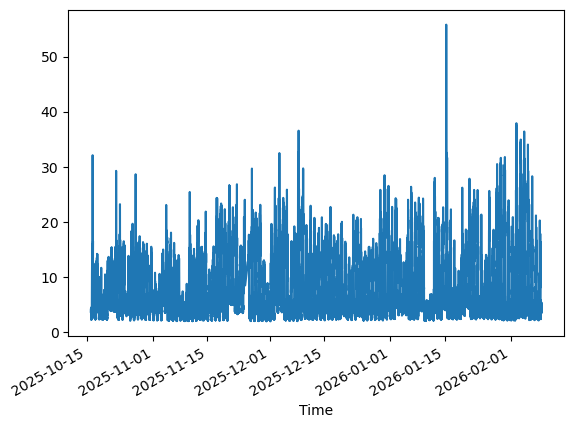

In [25]:
df_BU_TotActPwr_Academy.BU_TotActPwr_Academy.plot()

### Save load wise parquet

In [29]:
save_dir = Path(r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs")
save_dir.mkdir(parents=True, exist_ok=True)

file1 = save_dir / "df_BU_TotActPwr_Academy.parquet"
file2 = save_dir / "df_BU_TotActPwr_Tech_Room.parquet"
file3 = save_dir / "df_BA_TotActPwr_BESS_AC_Panel1.parquet"
file4 = save_dir / "df_BA_TotActPwr_BESS_AC_Panel2.parquet"

df_BU_TotActPwr_Academy.to_parquet(file1, engine="pyarrow")
df_BU_TotActPwr_Tech_Room.to_parquet(file2, engine="pyarrow")
df_BA_TotActPwr_BESS_AC_Panel1.to_parquet(file3, engine="pyarrow")
df_BA_TotActPwr_BESS_AC_Panel2.to_parquet(file4, engine="pyarrow")

print(file1)
print(file2)
print(file3)
print(file4)
print(file1.exists())
print(file2.exists())
print(file3.exists())
print(file4.exists())

C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\df_BU_TotActPwr_Academy.parquet
C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\df_BU_TotActPwr_Tech_Room.parquet
C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\df_BA_TotActPwr_BESS_AC_Panel1.parquet
C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\df_BA_TotActPwr_BESS_AC_Panel2.parquet
True
True
True
True
